# **Lista de Atividades**
**Autor:** Pedro Melo
**Disciplina:** Aprendizado Profundo
**Professor:** Tiago Maritan

### Importando bibliotecas

## Questão 3

Implemente e treine uma Rede Neural Convolucional (CNN) para resolver o problema de classificação de objetos em imagens utilizando a base de dados CIFAR-10, disponível em: https://www.cs.toronto.edu/~kriz/cifar.html. Apresente a curva do erro médio ao longo do treinamento, bem como a matriz de confusão do modelo avaliado sobre o conjunto de testes.


Sobre o CIFAR-10:

- 60 mil imagens divididas entre 10 classes (Cada classe com 6 mil imagens -> bom balanceamento)
- Imagens são 32 x 32 e coloridas (x3)

In [ ]:
import numpy as np
import keras
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
import glob
import random
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from keras.applications import ResNet50
from pathlib import Path
import os
from sklearn.metrics import confusion_matrix
import warnings
import json
import tensorflow as tf
from keras.callbacks import EarlyStopping
import pprint
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

### Resolução da questão a partir de classe com funções para construir, treinar e avaliar o modelo

In [ ]:
class CifarCNN:

    def __init__(self):

        warnings.filterwarnings("ignore")

        self.labels = {
            0: "Airplane",
            1: "Car",
            2: "Bird",
            3: "Cat",
            4: "Deer",
            5: "Dog",
            6: "Frog",
            7: "Horse",
            8: "Sheep",
            9: "Truck"
        }

        self.img_shape = (32, 32, 3) # rgb


    def load_transform_data(self):

        try:
            (X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()
            train_size = int(X_train_full.shape[0] * 0.8)

            print(f"Testando formato dos dados...")
            try:
                teste_formato = y_train_full.shape[1]
                teste_formato_2 = X_train_full.shape[3]
                print("Formatos das labels OK. Prosseguindo...")
            except:
                y_train = y_train.resize(y_train.shape[0], 1)
                y_test = y_test.resize(y_test.shape[0], 1)
                X_train_full = X_train_full.resize(X_train_full.shape[0], *self.img_shape)
                X_test_full = X_test_full.resize(X_test_full.shape[0], *self.img_shape)

            X_train, X_valid = X_train_full[:train_size], X_train_full[train_size:]

            if X_train[0].max() > 1:
                X_train = X_train / 255.0
                X_valid = X_valid / 255.0
                X_test = X_test / 255.0

            y_train, y_valid = y_train_full[:train_size], y_train_full[train_size:]


        except Exception as error:
            raise Exception(f"Não foi possível importar e tratar o conjunto de dados CIFAR-10: {error}") from error

        print("-" * 50)
        print("Resumo da base de dados: CIFAR-10")
        print("-" * 50)
        print(f"Formato do conjunto de treino: {X_train.shape}")
        print(f"Formato do conjunto de teste: {X_test.shape}")
        print(f"Formato do conjunto de validação: {X_valid.shape}")
        print(f"Formato do target: {y_train.shape}")
        print("-" * 50)

        self.X_train = X_train
        self.y_train = y_train

        self.X_test = X_test
        self.y_test = y_test

        self.X_valid = X_valid
        self.y_valid = y_valid

        return X_train, y_train, X_test, y_test, X_valid, y_valid


    def get_imgs_examples(self):

        imgs = []
        true_label = []

        for classe in range(10):

            idx_classe = np.where(self.y_train == classe)[0]
            idx_chosen = np.random.choice(idx_classe)

            imgs.append(self.X_train[idx_chosen])
            true_label.append(classe)

        imagens = np.array(imgs)

        plt.figure(figsize=(18, 8))

        for i in range(10):
            plt.subplot(2, 5, i+1)
            plt.imshow(imagens[i])
            plt.title(f"{self.labels[i]}")


        print("Exemplos de imagens do dataset CIFAR-10")
        plt.tight_layout()
        plt.show()


        return None


    def build_simple_model(self, num_conv_pooling:int=6,
                           num_filters:int=16,
                           kernel_size:tuple=(3, 3),
                           pool_size:tuple=(2,2),
                           conv_activation="relu",
                           dense_layers:int=4,
                           dense_neurons:int=32
                           ):

        try:
            model = Sequential([
                            Conv2D(num_filters, kernel_size,
                             activation=conv_activation,
                             padding="same",
                             input_shape=self.img_shape)
                        ])

            for i in range(1, num_conv_pooling + 1):

                if i > 1:
                    model.add(Conv2D(num_filters, kernel_size,
                                     padding="same",
                                    activation=conv_activation))

                model.add(Conv2D(num_filters, kernel_size,
                                 padding="same",
                                 activation=conv_activation))

                model.add(MaxPooling2D(pool_size))

            model.add(Flatten())
            for i in range(1, dense_layers + 1):
                model.add(Dense(dense_neurons // i, activation="relu"))

            model.add(Dense(10, activation="softmax"))

        except Exception as error:
            raise Exception(f"Não foi possível construir a CNN: {error}")

        return model


    def train_model(
            self,
            model_name,
            model: keras.Model,
            validation_set,
            batch_size, epochs,
            optimizer="adam"):

        try:
            model.compile(optimizer=optimizer,
                               loss="sparse_categorical_crossentropy",
                               metrics=["accuracy"])

            history = model.fit(
                self.X_train, self.y_train,
                batch_size=batch_size, epochs=epochs,
                validation_data=validation_set,
                verbose=False
                )

            pd.DataFrame(history.history).plot()
            plt.grid(True)
            plt.gca().set_ylim(0, 1)
            plt.title(f"Curva de aprendizagem: {model_name}")
            plt.show()

            self.batch_size = batch_size
            self.nome_rede = model_name

        except Exception as error:
            raise Exception(f"Não foi possível realizar o treinamento do modelo: {error}") from error

        return model


    def evaluate_model(
            self,
            trained_model):

        try:

            accuracy = trained_model.evaluate(self.X_test, self.y_test, batch_size=self.batch_size)[1]
            probas = trained_model.predict(self.X_test, batch_size=self.batch_size, verbose=False)
            predictions = np.argmax(probas, axis=1)
            conf_matrix = confusion_matrix(self.y_test, predictions)

            print(f"Acurácia do modelo {self.nome_rede}: {accuracy}")

            print(f"Matriz de Confusão do Modelo: ")
            print(conf_matrix)

        except Exception as error:

            raise Exception(f"Erro ao avaliar modelo: {error}") from error

        return accuracy


    def test_prediction(self, model):

        imgs = []
        true_label = []
        y_test = self.y_test.flatten()

        for classe in range(10):

            idx_classe = np.where(y_test == classe)[0]
            idx_chosen = np.random.choice(idx_classe)

            imgs.append(self.X_test[idx_chosen])
            true_label.append(classe)

        imagens = np.array(imgs)

        preds = model.predict(imagens, verbose=0)
        class_preds = np.argmax(preds, axis=1)

        plt.figure(figsize=(18, 8))

        for i in range(10):
            plt.subplot(2, 5, i+1)
            plt.imshow(imagens[i])
            plt.axis("off")

            plt.title(f"Classe real: {self.labels[true_label[i]]}. Clase Predita: {self.labels[class_preds[i]]}")

        plt.tight_layout()
        plt.show()

        return None


    def chose_best_model(self, results_dict: dict[keras.Model]):

        try:
            results_sorted = dict(sorted(results_dict.items(), key=lambda x: x[1], reverse=True))
            resultados_consolidados = {}
            print(results_sorted)
            for rede, res in results_sorted.items():

                items = rede.split("_")
                conv_pool, batch, epochs = items[1], items[2], items[3]

                print(f"Resultados da aplicação da Rede {rede}")
                print(f"Camadas Conv-Pool: {conv_pool}")
                print(f"Tamanho do Batch: {batch}")
                print(f"Nº de épocas: {epochs}")
                print(f"Acurácia: {round(res, 2)}")
                print("-"*50)

                resultados_consolidados[rede] = {
                    "conv_pool_layers": conv_pool,
                    "batch_size": batch,
                    "epochs": epochs,
                    "accuracy": res
                }


            with open("results.json", "w") as file:

                json.dump(resultados_consolidados, file)

            best_model = list(results_sorted.keys())[0]
            print(f"Números do melhor modelo: {resultados_consolidados[best_model]}")

        except Exception as error:
            raise Exception(f"Não foi possível avaliar o melhor modelo: {error}") from error

        return best_model


    def tune_resnet(self, dense_layers:int,
                    dense_neurons:int=128):

        try:

            nn = Sequential()
            resnet = ResNet50(include_top=False,
                              input_shape=self.img_shape,
                              pooling="max", classes=len(self.labels.keys()))
            for layer in resnet.layers:
                layer.trainable = False

            nn.add(resnet)
            nn.add(Flatten())
            for i in range(1, dense_layers+1):
                nn.add(Dense(dense_neurons//i))
            nn.add(Dense(10, activation="softmax"))

        except Exception as error:
            raise Exception(f"Não foi possível construir a ResNet: {error}") from error

        return nn

## Rotina de Criação e Avaliação das Redes

Sucesso! Usando GPU em: /device:GPU:0
Testando formato dos dados...
Formatos das labels OK. Prosseguindo...
--------------------------------------------------
Resumo da base de dados: CIFAR-10
--------------------------------------------------
Formato do conjunto de treino: (40000, 32, 32, 3)
Formato do conjunto de teste: (10000, 32, 32, 3)
Formato do conjunto de validação: (10000, 32, 32, 3)
Formato do target: (40000, 1)
--------------------------------------------------
Exemplos de imagens do dataset CIFAR-10


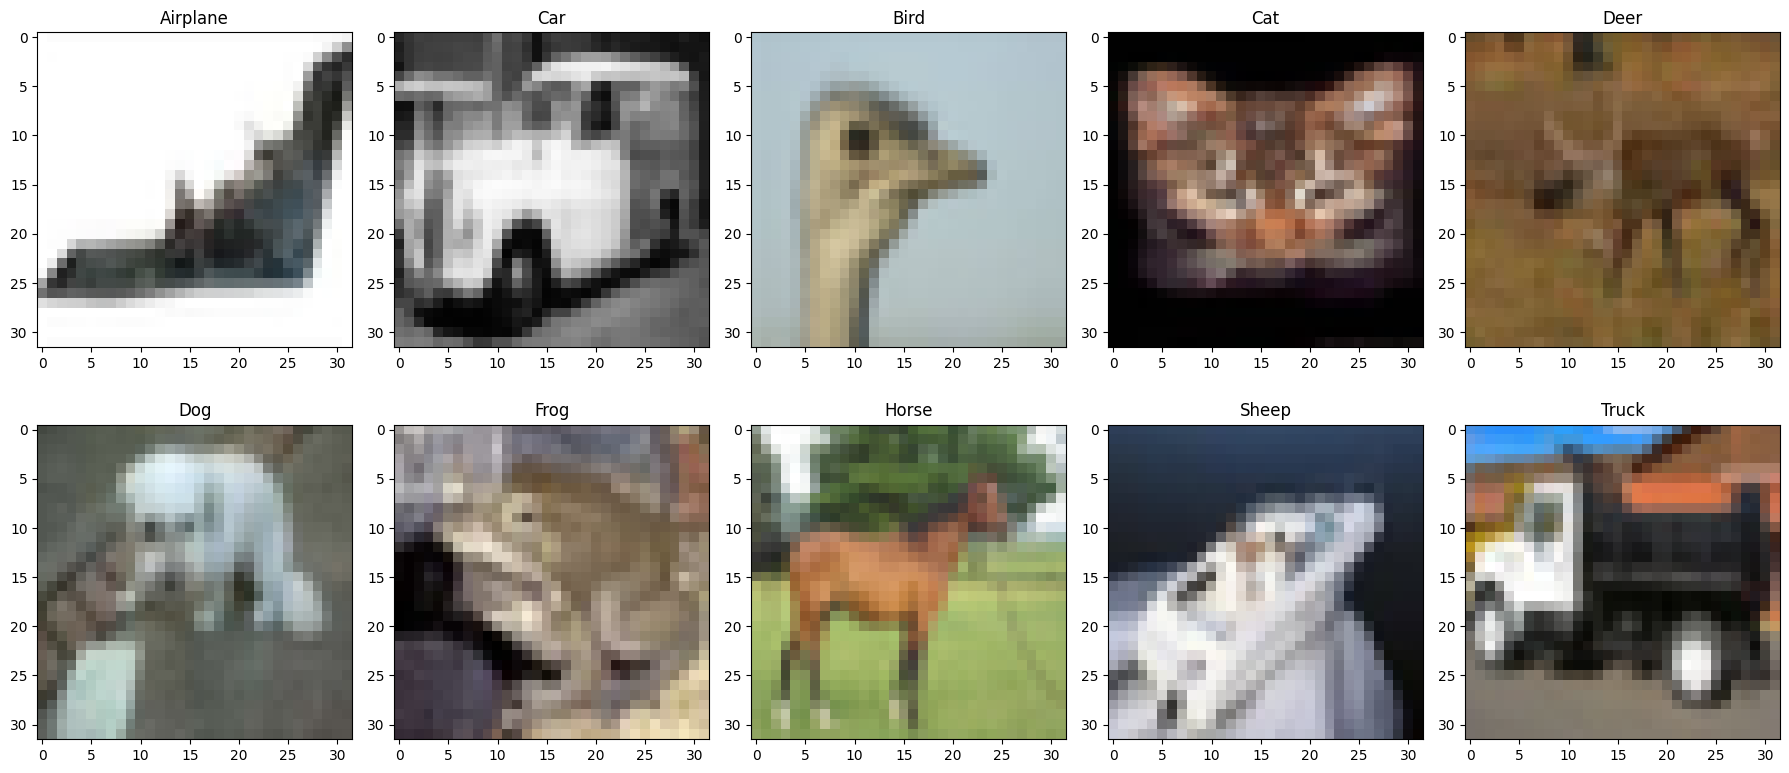

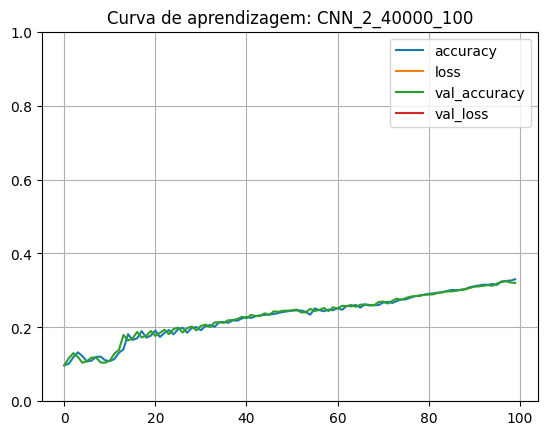

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.3258 - loss: 1.8610
Acurácia do modelo CNN_2_40000_100: 0.32580000162124634
Matriz de Confusão do Modelo: 
[[468 107  21  31  38   0  31 118 186   0]
 [ 16 711   0  13  10   0  51  78 121   0]
 [104  56  52  71 477   0  98 126  16   0]
 [ 31 132  52 167 381   0 156  80   1   0]
 [ 43  33  33  49 609   0  62 161  10   0]
 [ 23  95  32 165 406   0 144 124  11   0]
 [  5  66  25  79 531   0 231  63   0   0]
 [ 27  60   8  44 239   0  78 536   8   0]
 [148 233   7  26  21   0  22  59 484   0]
 [ 28 690   1  16  22   0  50  82 111   0]]


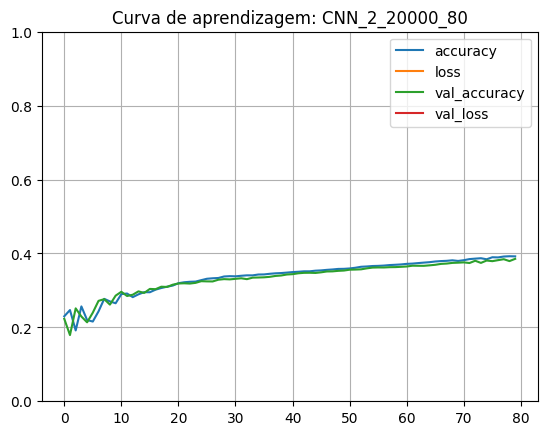

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.3914 - loss: 1.6127
Acurácia do modelo CNN_2_20000_80: 0.391400009393692
Matriz de Confusão do Modelo: 
[[566  35  17  34  32   9  20  56 173  58]
 [ 32 501   0  18   1  10  22  27 134 255]
 [108  26 200 122 230  27 119 135  11  22]
 [ 33  65 102 235  85  64 285  90   7  34]
 [ 56  13 200  71 254  33 147 203   9  14]
 [ 26  35 114 186 136  46 278 155   8  16]
 [ 10  41 124 133  86  48 434  94   3  27]
 [ 36  15  18  42  89  45  87 616   6  46]
 [200  88   3  41   2   2   7  19 553  85]
 [ 53 228   1  15   0  13  26  64  91 509]]


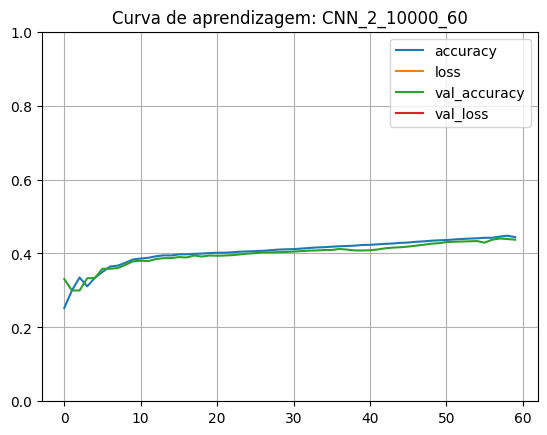

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.4381 - loss: 1.4938
Acurácia do modelo CNN_2_10000_60: 0.43810001015663147
Matriz de Confusão do Modelo: 
[[613  33  48  16   8   9   9  21 196  47]
 [ 50 631   3  12   0   9   6   8 118 163]
 [139  19 214 103 245  52  59 112  33  24]
 [ 51  44 113 239  65 103 212 102  28  43]
 [ 79  14 151  83 343  58  56 181  21  14]
 [ 31  23  93 157 117 156 219 160  22  22]
 [ 20  32  70 221 104 101 317  82  15  38]
 [ 70   9  39  27  68  50  24 650  12  51]
 [159  83  12  10   0   1   4   6 675  50]
 [ 65 221   3  21   3   7   9  39  89 543]]


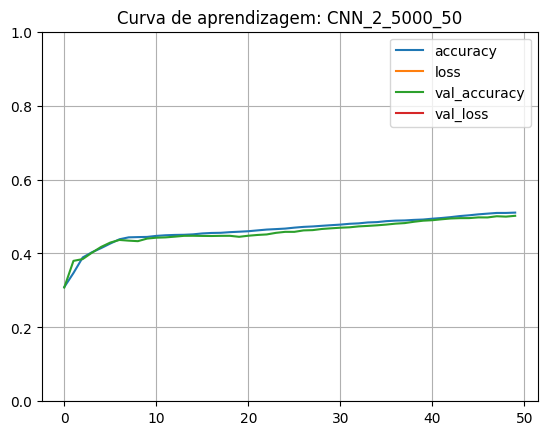

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5060 - loss: 1.3505 
Acurácia do modelo CNN_2_5000_50: 0.504800021648407
Matriz de Confusão do Modelo: 
[[640  27  64  12  18   5  16  23 155  40]
 [ 43 693   5   6   0   8  16   8  64 157]
 [108  14 343  53 183  91  71  79  38  20]
 [ 26  25 115 193  76 172 262  68  22  41]
 [ 50   6 217  53 345  87  75 131  25  11]
 [ 15  10  98 106  68 349 179 148  12  15]
 [ 12  20  89 141  71  90 506  30  13  28]
 [ 37   2  24  30  87  78  17 681   5  39]
 [120  91  25  11   3   1   7   9 693  40]
 [ 51 178   4  23   7   3  18  32  79 605]]


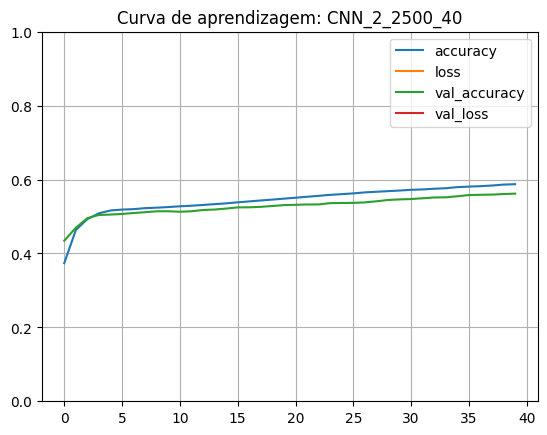

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5539 - loss: 1.2275


Acurácia do modelo CNN_2_2500_40: 0.5548999905586243
Matriz de Confusão do Modelo: 
[[589  26  73   7  20   5  18  16 203  43]
 [ 30 664   1   7   1   2  19   8  72 196]
 [ 90  12 317  52 200  88  93  80  47  21]
 [ 14  15  80 277 109 176 149  87  32  61]
 [ 37   3 115  84 475  33  76 138  28  11]
 [  7   6  79 186  61 413  65 151  16  16]
 [  5  23  57 130  87  29 599  11  27  32]
 [ 22   1  25  43  71  64   5 720   8  41]
 [ 55  54  18   6   5   2  10  10 791  49]
 [ 27 108   2  12   9   3  18  24  93 704]]


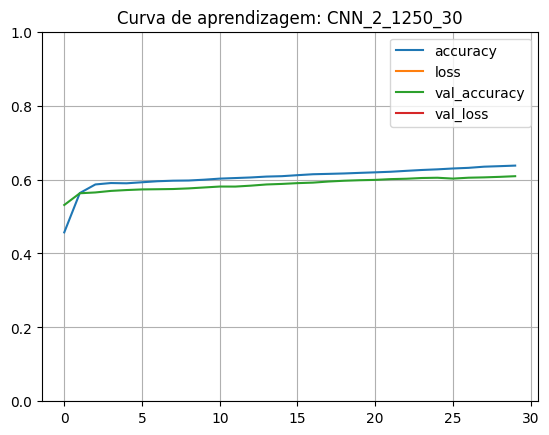

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6065 - loss: 1.0991


Acurácia do modelo CNN_2_1250_30: 0.6089000105857849
Matriz de Confusão do Modelo: 
[[687  41  82   8  20   5  11  15 101  30]
 [ 41 787   2   7   0   2  15   8  30 108]
 [ 87  15 415  62 143  96  87  60  20  15]
 [ 20  24 108 333  67 185 136  77  23  27]
 [ 31   2 111  80 532  11  97 108  20   8]
 [  5   9  92 198  40 487  46 101  11  11]
 [  3  23  55 114  41  24 710   5  14  11]
 [ 26   4  29  52  64  66   3 722   5  29]
 [ 89  64  12  14   9   4  11   5 749  43]
 [ 48 154   4  22   5   3  15  30  52 667]]


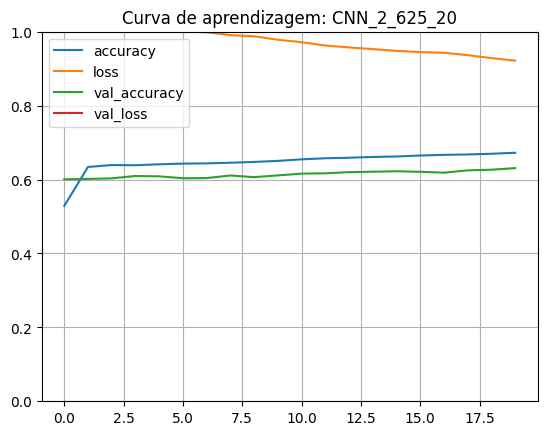

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6349 - loss: 1.0429
Acurácia do modelo CNN_2_625_20: 0.6340000033378601
Matriz de Confusão do Modelo: 
[[672  35 111  13  24   9  10  21  66  39]
 [ 26 758   6   8   3   4  17  12  16 150]
 [ 68   7 458  42 145 144  68  44   9  15]
 [ 11  12  94 315  93 273 109  66  10  17]
 [ 21   1 104  50 617  30  70  89  13   5]
 [  5   5  81 120  53 605  39  81   1  10]
 [  2  11  56  78  67  34 737   4   4   7]
 [ 13   1  34  29  83 103   3 719   1  14]
 [ 87  56  18  41  13   5  14   6 716  44]
 [ 34  92   5  23  12   7  10  42  32 743]]


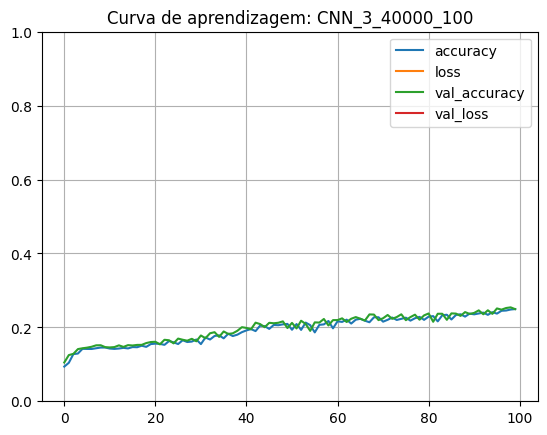

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.2545 - loss: 2.0191
Acurácia do modelo CNN_3_40000_100: 0.25450000166893005
Matriz de Confusão do Modelo: 
[[581  45   1  31   0  18  15   0 255  54]
 [172 208   2 137   0 110   7   1 140 223]
 [397  54   9 135   0 179  70   2  79  75]
 [141  39   4 267   0 364  63   0  27  95]
 [377  49  12  79   0 238 108   4  77  56]
 [150  59   0 258   0 395  41   1  34  62]
 [186  44  12 200   0 332 129   5  35  57]
 [180 151   0 130   0 179  60   3  55 242]
 [279  29   1  21   0  57   5   1 506 101]
 [ 76  95   0 127   0  45  18   4 188 447]]


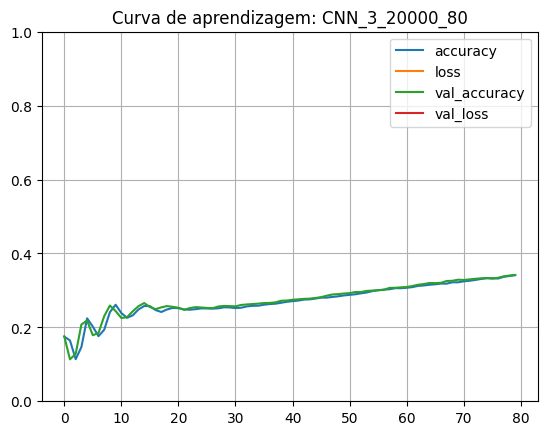

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step - accuracy: 0.3424 - loss: 1.7735
Acurácia do modelo CNN_3_20000_80: 0.3424000144004822
Matriz de Confusão do Modelo: 
[[453  86  97  14   1   6  26  35 238  44]
 [ 46 506   5  42   0  12  12  59  89 229]
 [102  33 294 105   4 148 204  43  40  27]
 [ 35  27  90 242   3 273 217  52  13  48]
 [ 63  23 290  67   4  95 331  62  47  18]
 [ 19  15  98 212   2 317 252  44  17  24]
 [ 11  17 129 145   2 140 455  73   3  25]
 [ 57 129  71 122   4  54 246 190  29  98]
 [187  89  47  17   0  22  13  26 494 105]
 [ 27 244  14  53   0   7  31  54 101 469]]


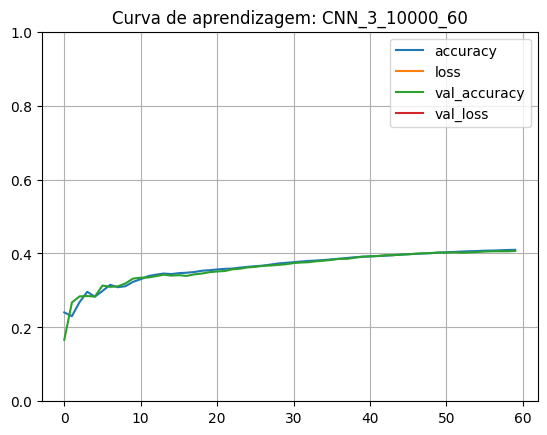

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.4134 - loss: 1.5922
Acurácia do modelo CNN_3_10000_60: 0.41339999437332153
Matriz de Confusão do Modelo: 
[[530  60  71  11  17  14   4  46 203  44]
 [ 54 602   2  16   1  10   7  38 105 165]
 [100  20 301  49 112 135 124  95  38  26]
 [ 29  22 112 148  34 282 173 121  26  53]
 [ 70  12 205  33 236  71 166 160  31  16]
 [ 18  15 102  96  51 424 129 111  30  24]
 [ 11  10  88  70 103 101 404 173   4  36]
 [ 51  40  31  44  57 110  76 496  24  71]
 [192 115  39  17   0  17   1  22 518  79]
 [ 40 264   6  32   4   6   4  62 107 475]]


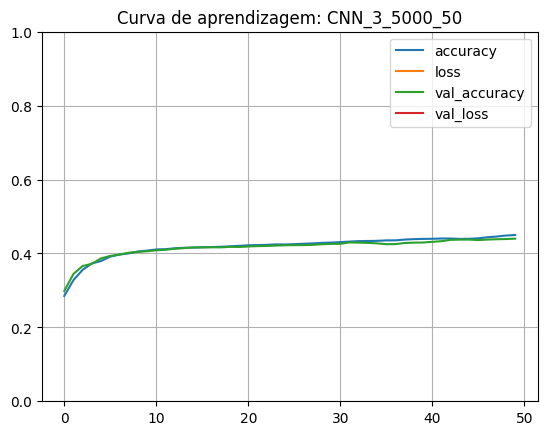

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.4375 - loss: 1.5145
Acurácia do modelo CNN_3_5000_50: 0.43700000643730164
Matriz de Confusão do Modelo: 
[[540  62  58   9  16  23   6  40 206  40]
 [ 45 653   1  12   0   8   7  34  95 145]
 [105  17 286  66 124 163  85  98  33  23]
 [ 30  21 105 186  35 296 137 109  30  51]
 [ 72  14 181  37 235 109 144 170  27  11]
 [ 19  17  88 112  46 462  88 124  26  18]
 [  7  10  84 108  69  94 447 138   8  35]
 [ 54  33  19  48  53 127  56 543  12  55]
 [174 122  25  18   2  10   1  15 568  65]
 [ 38 313   4  32   5   9   6  46  97 450]]


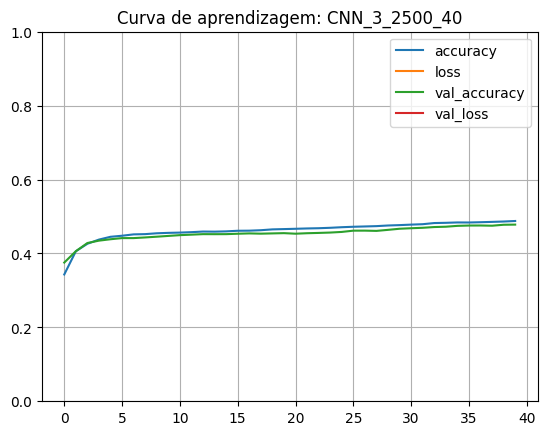

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4835 - loss: 1.4183
Acurácia do modelo CNN_3_2500_40: 0.48030000925064087
Matriz de Confusão do Modelo: 
[[564  55  70  19  24  26   6  44 149  43]
 [ 47 699   0  18   1  11   7  39  56 122]
 [ 73   8 276  95 162 151  89 105  25  16]
 [ 18  16  99 211  37 319 144 110  10  36]
 [ 53   8 139  43 289 103 156 191  14   4]
 [ 13   5  81 113  60 481  77 144  15  11]
 [  4   2  40 106  89  60 574 102   7  16]
 [ 28  20  16  41  53 126  56 634   5  21]
 [164 105  31  23   3  17   1  17 584  55]
 [ 43 267   9  42   4  11   8  58  67 491]]


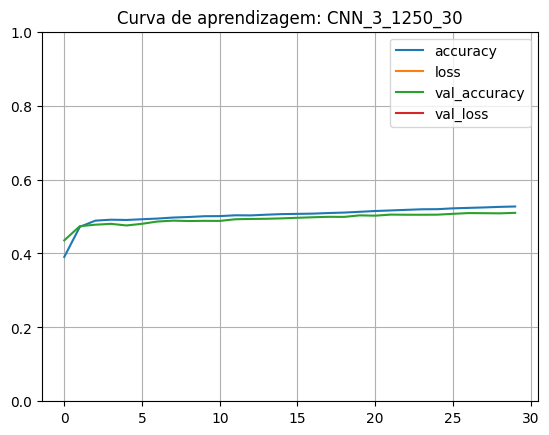

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5125 - loss: 1.3376
Acurácia do modelo CNN_3_1250_30: 0.5101000070571899
Matriz de Confusão do Modelo: 
[[642  59  78  18  10   7   7  52  80  47]
 [ 40 751   0  11   1   6   6  21  27 137]
 [ 83  11 356  78 151  84  81 114  18  24]
 [ 26  19 133 252  42 223 136 110  15  44]
 [ 57   8 161  48 304  59 139 203   8  13]
 [ 14   7 117 148  53 385  77 161  20  18]
 [  7   5  46  95 100  30 605  79   3  30]
 [ 37  17  30  34  49  81  49 665   4  34]
 [170 105  23  25   1   5   1   9 599  62]
 [ 40 275   8  26   4   4   9  46  46 542]]


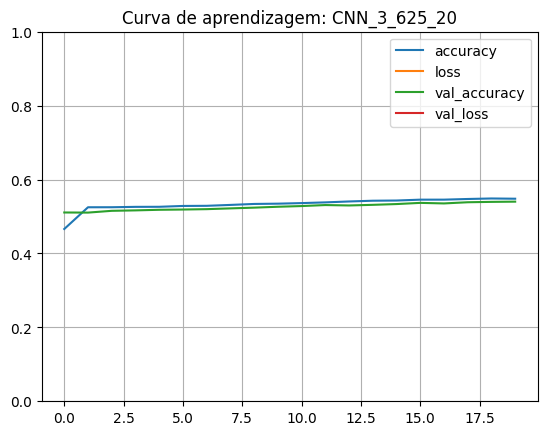

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5368 - loss: 1.2651
Acurácia do modelo CNN_3_625_20: 0.534600019454956
Matriz de Confusão do Modelo: 
[[619  40  79  15   8  11   8  24 139  57]
 [ 31 750   0  10   5   5   7  12  42 138]
 [ 99  15 366  81 149 109  69  68  23  21]
 [ 32  18 120 304  39 253 120  43  31  40]
 [ 59   7 159  63 349  73 138 124  12  16]
 [ 18   5 111 182  50 437  65  96  22  14]
 [  5   4  47 118  92  41 616  37  12  28]
 [ 47  16  33  33  82 102  44 606   3  34]
 [100  74  19  25   2   5   1   4 732  38]
 [ 42 236   5  22   6  10   6  39  67 567]]


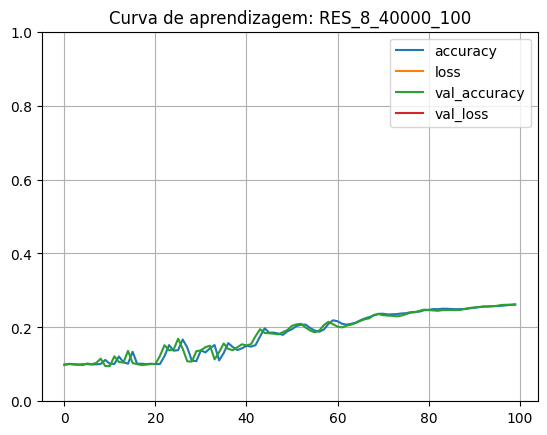

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 726ms/step - accuracy: 0.2630 - loss: 2.0374
Acurácia do modelo RES_8_40000_100: 0.2630000114440918
Matriz de Confusão do Modelo: 
[[274 127 122  10  51  33  50  90 193  50]
 [105 267  18  12  18  47  15  72 143 303]
 [ 78  25 275  44 150 121  52 114  91  50]
 [ 30  36 145  76  94 196  61 168  94 100]
 [ 50  22 213  25 233  72  81  73 174  57]
 [ 23  18 187  79  99 267  29 162  58  78]
 [ 72  34 185  25 191  60  96  88 192  57]
 [ 30  43 104  36  42 119  75 330  46 175]
 [138 190  38   8  38  78  44  22 354  90]
 [ 39 171  25   9  14  36  43  93 112 458]]


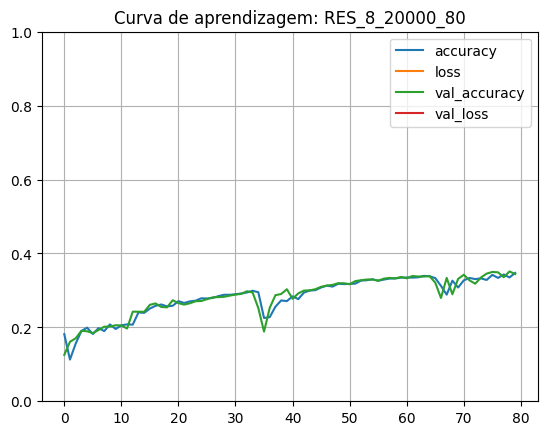

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 719ms/step - accuracy: 0.3458 - loss: 1.8222
Acurácia do modelo RES_8_20000_80: 0.3458000123500824
Matriz de Confusão do Modelo: 
[[332  69  59  17  67  30  41  20 332  33]
 [ 48 326   3  36   8  38  24  22 257 238]
 [117  30 152  77 215 194  74  32  79  30]
 [ 47  50  53 154 114 283  86  62  71  80]
 [ 47  21  69  95 355 105 117  47 114  30]
 [ 21  25  44 135 115 445  46  55  54  60]
 [ 58  78  62  90 149  76 260  24 150  53]
 [ 42  45  50  85  89 186  24 294  49 136]
 [ 88  82   8  18  33  52  11   5 647  56]
 [ 21 124   5  46  21  47  22  31 190 493]]


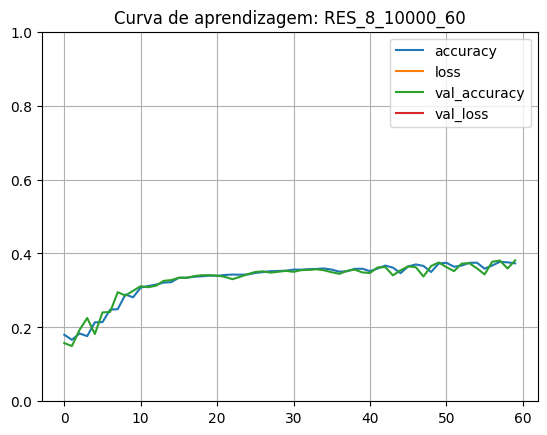

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 695ms/step - accuracy: 0.3845 - loss: 1.7303
Acurácia do modelo RES_8_10000_60: 0.38449999690055847
Matriz de Confusão do Modelo: 
[[411  57 100   6  63  17  55  42 221  28]
 [ 55 372   9  18  23  27  78  66 130 222]
 [100  29 213  35 225 131 107  97  37  26]
 [ 38  42  76 111 147 234 123 132  34  63]
 [ 44  21  88  62 417  79 131  89  44  25]
 [ 19  27  74  87 124 377  61 163  30  38]
 [ 37  75  89  52 162  59 391  55  36  44]
 [ 26  32  58  35  85 117  38 491  21  97]
 [131  83  19  15  46  41  25  19 560  61]
 [ 33 117   7  36  24  26  47  83 125 502]]


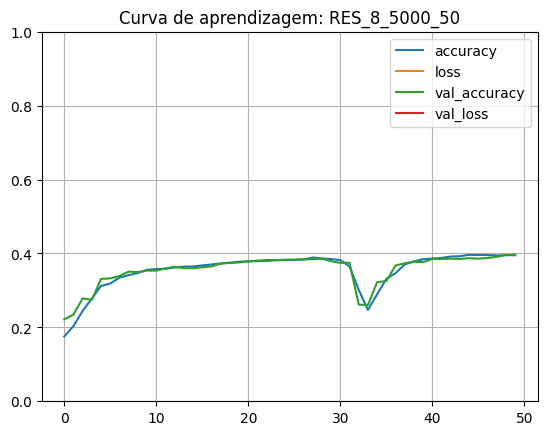

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 322ms/step - accuracy: 0.3903 - loss: 1.7099
Acurácia do modelo RES_8_5000_50: 0.38920000195503235
Matriz de Confusão do Modelo: 
[[435  82  82   5  41  10  26  49 221  49]
 [ 46 448   5   8  10  16  34  66  95 272]
 [110  35 209  27 199 105  79 152  45  39]
 [ 36  73  63  74 117 212  92 211  38  84]
 [ 52  40  77  21 373  52  92 210  41  42]
 [ 20  47  68  60  91 341  44 242  28  59]
 [ 40 139  71  33 164  62 297  87  37  70]
 [ 22  42  35  19  58  74  18 588  21 123]
 [131 102  18   8  20  26  12  29 553 101]
 [ 30 125   7  12  19  17  20  87 109 574]]


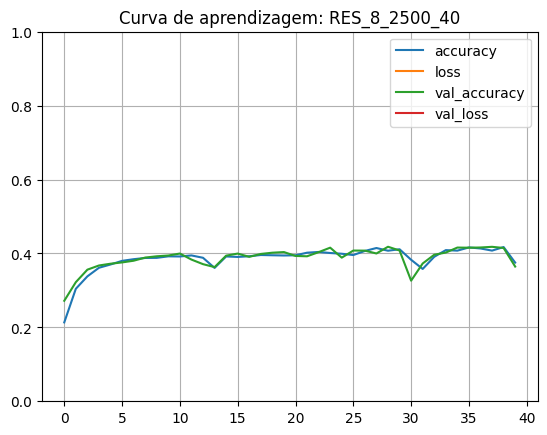

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 156ms/step - accuracy: 0.3638 - loss: 1.7711
Acurácia do modelo RES_8_2500_40: 0.36390000581741333
Matriz de Confusão do Modelo: 
[[339  74 307  24  66  48  33   7  28  74]
 [ 31 449  32  32  27  98  54   8   8 261]
 [ 32  26 424  44 145 249  40  10   4  26]
 [ 13  41 141 141  96 444  52  14   0  58]
 [ 20  18 190  45 415 216  50  16   1  29]
 [  5  19 116  60  68 652  26  16   0  38]
 [  5  71 178  65 145 197 294   3   0  42]
 [ 11  38 113  45  87 375  16 198   1 116]
 [214 137 144  20  74  80  24   5 128 174]
 [ 27 131  32  34  29 105  19  15   9 599]]


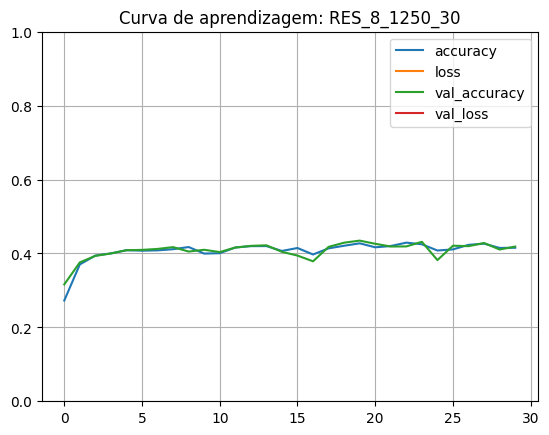

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.4185 - loss: 1.6362
Acurácia do modelo RES_8_1250_30: 0.41609999537467957
Matriz de Confusão do Modelo: 
[[482  68 176   6  11   2  52  21 120  62]
 [ 47 511  19   5   4   4  84  29  61 236]
 [ 90  29 505  19  35  50 134  77  23  38]
 [ 39  69 250  91  36 118 200  90  15  92]
 [ 39  38 302  20 180  10 253  93  20  45]
 [ 11  52 239  52  34 271 108 129  12  92]
 [ 19  77 158  12  16  21 599  39  11  48]
 [ 19  54 137  10  28  42  75 458  13 164]
 [183 120  70  10   5  11  32   7 459 103]
 [ 33 155  32  12   9   9  46  39  60 605]]


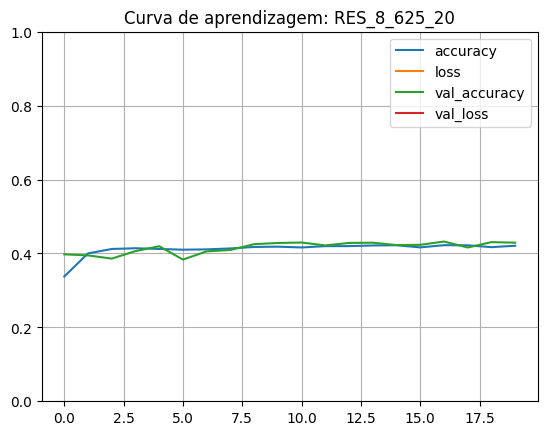

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4364 - loss: 1.6189
Acurácia do modelo RES_8_625_20: 0.43290001153945923
Matriz de Confusão do Modelo: 
[[609  63  39   9  52   3  29  18 142  36]
 [ 64 549   3   6  16   3  66  28  74 191]
 [190  35 181  58 251  65  93  65  29  33]
 [ 96  78  53 150 177 118 145  94  21  68]
 [ 79  37  50  28 510   9 150  84  26  27]
 [ 46  55  60 115 159 279  75 118  22  71]
 [ 58  97  43  29 160  17 509  35  20  32]
 [ 63  63  33  25 123  44  50 464  14 121]
 [210 104   9  11  25  10  21   7 518  85]
 [ 61 168   5  15  22  11  37  38  83 560]]


In [ ]:

from pprint import pprint

# Verificar se a GPU está disponível
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('Aviso: GPU não encontrada. O treinamento será mais lento no modo CPU.')
else:
    print(f'Sucesso! Usando GPU em: {device_name}')

cifar_cnn = CifarCNN()
X_train, y_train, X_test, y_test, X_valid, y_valid = cifar_cnn.load_transform_data()
validation_set = (X_valid, y_valid)
cifar_cnn.get_imgs_examples()

testing_models = {
    "CNN_2": cifar_cnn.build_simple_model(num_conv_pooling=2, num_filters=16,
                                          dense_layers=4, dense_neurons=32),
    "CNN_3": cifar_cnn.build_simple_model(num_conv_pooling=3, num_filters=8,
                                          dense_layers=6, dense_neurons=64),

    "RES_8": cifar_cnn.tune_resnet(8, dense_neurons=256),
}

full_epoch_size = X_train.shape[0]

batchs_epochs_combination = {
    full_epoch_size: 100,
    full_epoch_size//2: 80,
    full_epoch_size//4: 60,
    full_epoch_size//8: 50,
    full_epoch_size//16: 40,
    full_epoch_size//32: 30,
    full_epoch_size//64: 20,
}

results_dict = {}

for name, model in testing_models.items():

    for batch_size, epochs in batchs_epochs_combination.items():

        model_name = f"{name}_{batch_size}_{epochs}"

        trained_model = cifar_cnn.train_model(model_name, model,
                              validation_set, batch_size, epochs)

        model_result = cifar_cnn.evaluate_model(trained_model)

        results_dict[model_name] = model_result

In [ ]:
best_model = cifar_cnn.chose_best_model(
    results_dict
)

{'CNN_2_625_20': 0.6340000033378601, 'CNN_2_1250_30': 0.6089000105857849, 'CNN_2_2500_40': 0.5548999905586243, 'CNN_3_625_20': 0.534600019454956, 'CNN_3_1250_30': 0.5101000070571899, 'CNN_2_5000_50': 0.504800021648407, 'CNN_3_2500_40': 0.48030000925064087, 'CNN_2_10000_60': 0.43810001015663147, 'CNN_3_5000_50': 0.43700000643730164, 'RES_8_625_20': 0.43290001153945923, 'RES_8_1250_30': 0.41609999537467957, 'CNN_3_10000_60': 0.41339999437332153, 'CNN_2_20000_80': 0.391400009393692, 'RES_8_5000_50': 0.38920000195503235, 'RES_8_10000_60': 0.38449999690055847, 'RES_8_2500_40': 0.36390000581741333, 'RES_8_20000_80': 0.3458000123500824, 'CNN_3_20000_80': 0.3424000144004822, 'CNN_2_40000_100': 0.32580000162124634, 'RES_8_40000_100': 0.2630000114440918, 'CNN_3_40000_100': 0.25450000166893005}
Resultados da aplicação da Rede CNN_2_625_20
Camadas Conv-Pool: 2
Tamanho do Batch: 625
Nº de épocas: 20
Acurácia: 0.63
--------------------------------------------------
Resultados da aplicação da Rede CN

## Tentando melhorar acurácia e generalização com 3 coisas:

- Dropout
- Batch Normalization
- Data Augmentation

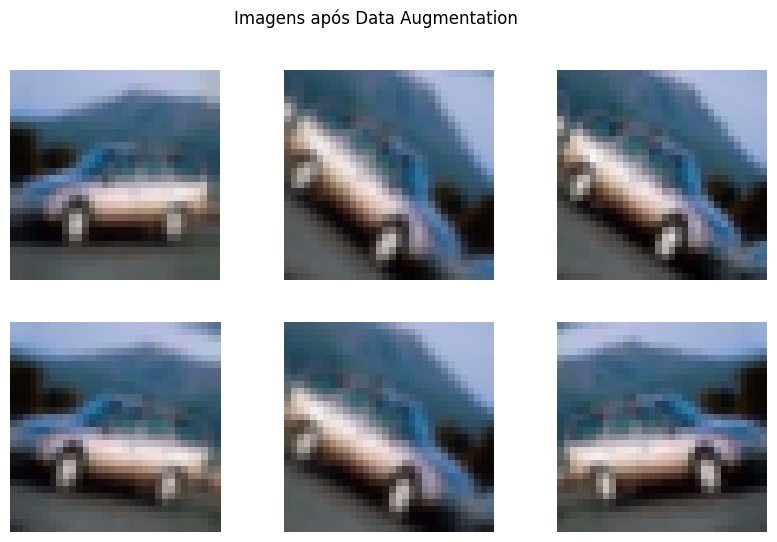

In [ ]:
# best_model: conv-pool 2, batch size 625 e 20 epochs

from keras.layers import (
    RandomFlip, RandomRotation,
    RandomZoom, BatchNormalization,
    Dropout
)

data_aug_layers = Sequential(
    [
        RandomFlip("horizontal"),
        RandomRotation(0.1),
        RandomZoom(0.1)
    ]
)

# exemplo de imagens rotacionadas
plt.figure(figsize=(10,6))
image = X_train[4]
for i in range(6):
    ax = plt.subplot(2, 3, i+1)
    aug_img = data_aug_layers(np.expand_dims(image, 0), training=True)
    plt.imshow(aug_img[0])
    plt.axis("off")

plt.suptitle("Imagens após Data Augmentation")
plt.show()

In [ ]:
# melhorando funcao de construcao da rede


def build_new_cnn(num_conv_pool:int=2,
                  num_filters:int=32,
                  kernel_size:tuple=(3,3),
                  pool_size:tuple=(2,2),
                  conv_activation:str="relu",
                  dense_layers:int=2,
                  dense_neurons:int=64,
                  dropout_conv:float=.25,
                  dropout_dense=.5):

    try:

        model = Sequential([
            data_aug_layers,
            Conv2D(filters=num_filters,
                   kernel_size=kernel_size,
                   input_shape=(32, 32, 3)),
            BatchNormalization()
        ])

        for i in range(1, num_conv_pool + 1):

            if i > 1:
                model.add(Conv2D(num_filters * (2 ** i-1), kernel_size,
                                    padding="same",
                                activation=conv_activation))
                model.add(BatchNormalization())

            model.add(Conv2D(num_filters * (2 ** i-1), kernel_size,
                                padding="same",
                                activation=conv_activation))
            model.add(BatchNormalization())
            model.add(MaxPooling2D(pool_size))
            model.add(Dropout(dropout_conv))

        model.add(Flatten())

        for i in range(1, dense_layers + 1):
            model.add(Dense(dense_neurons // i, activation="relu"))
            model.add(BatchNormalization())
            model.add(Dropout(dropout_dense))

        model.add(Dense(10, activation="softmax"))

        return model

    except Exception as error:
        raise Exception(f"Erro ao construir a nova CNN: {error}") from error


new_nn = build_new_cnn()
new_nn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (1, 32, 32, 3)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (1, 30, 30, 32)        │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (1, 30, 30, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (1, 30, 30, 32)        │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (1, 30, 30, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (1, 15, 15, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (1, 15, 15, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (1, 15, 15, 96)        │        27,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (1, 15, 15, 96)        │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (1, 15, 15, 96)        │        83,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (1, 15, 15, 96)        │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (1, 7, 7, 96)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (1, 7, 7, 96)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (1, 4704)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (1, 64)                │       301,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (1, 64)                │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (1, 64)                │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (1, 32)                │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (1, 32)                │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (1, 32)                │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (1, 10)                │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,866 (1.62 MB)

 Trainable params: 425,162 (1.62 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# nova funcao de treino


def new_train_model(
        model_name,
        model: keras.Model,
        X_train, y_train,
        validation_set,
        batch_size, epochs,
        optimizer="adam",
        callbacks=None):

    try:
        print(f"Treinando modelo {model_name}")
        model.compile(optimizer=optimizer,
                            loss="sparse_categorical_crossentropy",
                            metrics=["accuracy"])

        history = model.fit(
            X_train, y_train,
            batch_size=batch_size, epochs=epochs,
            validation_data=validation_set,
            verbose=True, callbacks=[callbacks]
            )

        pd.DataFrame(history.history).plot()
        plt.grid(True)
        plt.gca().set_ylim(0, 1)
        plt.title(f"Curva de aprendizagem: {model_name}")
        plt.show()

    except Exception as error:
        raise Exception(f"Não foi possível realizar o treinamento do modelo: {error}") from error

    return model

Treinando modelo New CNN 3
Epoch 1/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 22s 139ms/step - accuracy: 0.1767 - loss: 2.7162 - val_accuracy: 0.1041 - val_loss: 3.6954
Epoch 2/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.2995 - loss: 1.9762 - val_accuracy: 0.1146 - val_loss: 4.3860
Epoch 3/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.3761 - loss: 1.7235 - val_accuracy: 0.1639 - val_loss: 2.9609
Epoch 4/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 0.4236 - loss: 1.6056 - val_accuracy: 0.1910 - val_loss: 3.9906
Epoch 5/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.4606 - loss: 1.5065 - val_accuracy: 0.3647 - val_loss: 1.9172
Epoch 6/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.4974 - loss: 1.4208 - val_accuracy: 0.5553 - val_loss: 1.3063
Epoch 7/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 107ms/step - accuracy: 0.5242 - loss: 1.3607 - val_accuracy: 0.6098 - val_loss: 1.1294
Epoch 8/60
88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 108ms/step - accuracy: 0.5464

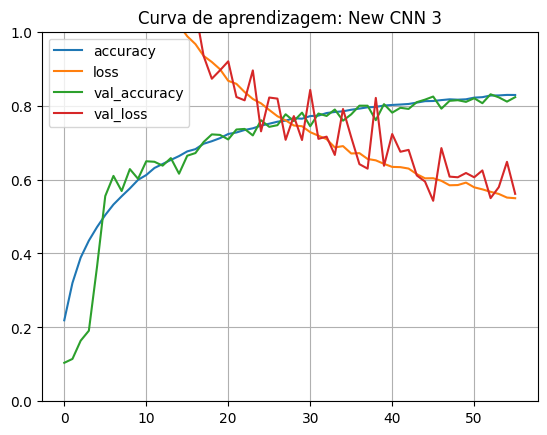

In [ ]:
early_stopping = EarlyStopping("val_loss", patience=10, restore_best_weights=True)
new_nn_3 = build_new_cnn(3)

trained_cnn3 = new_train_model(
    "New CNN 3",
    new_nn_3,
    X_train,
    y_train,
    validation_set,
    456,
    60,
    callbacks=early_stopping
    )

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8209 - loss: 0.5427
Acurácia do modelo New CNN 3: 0.8216999769210815
Matriz de Confusão do Modelo: 
[[828  32  24   9   6   6   1  13  48  33]
 [  5 922   0   3   0   1   1   1   8  59]
 [ 56   7 720  35  38  53  54  22   9   6]
 [ 12  10  41 619  35 152  70  28   7  26]
 [ 11   0  43  42 769  30  57  42   5   1]
 [  5   4  21 101  25 764  32  38   5   5]
 [  3   3  10  27  11  10 919   1   7   9]
 [  6   2   8  21  41  44   6 862   1   9]
 [ 29  13   3  11   2   2   2   1 912  25]
 [ 14  54   2   4   0   3   4   4  13 902]]


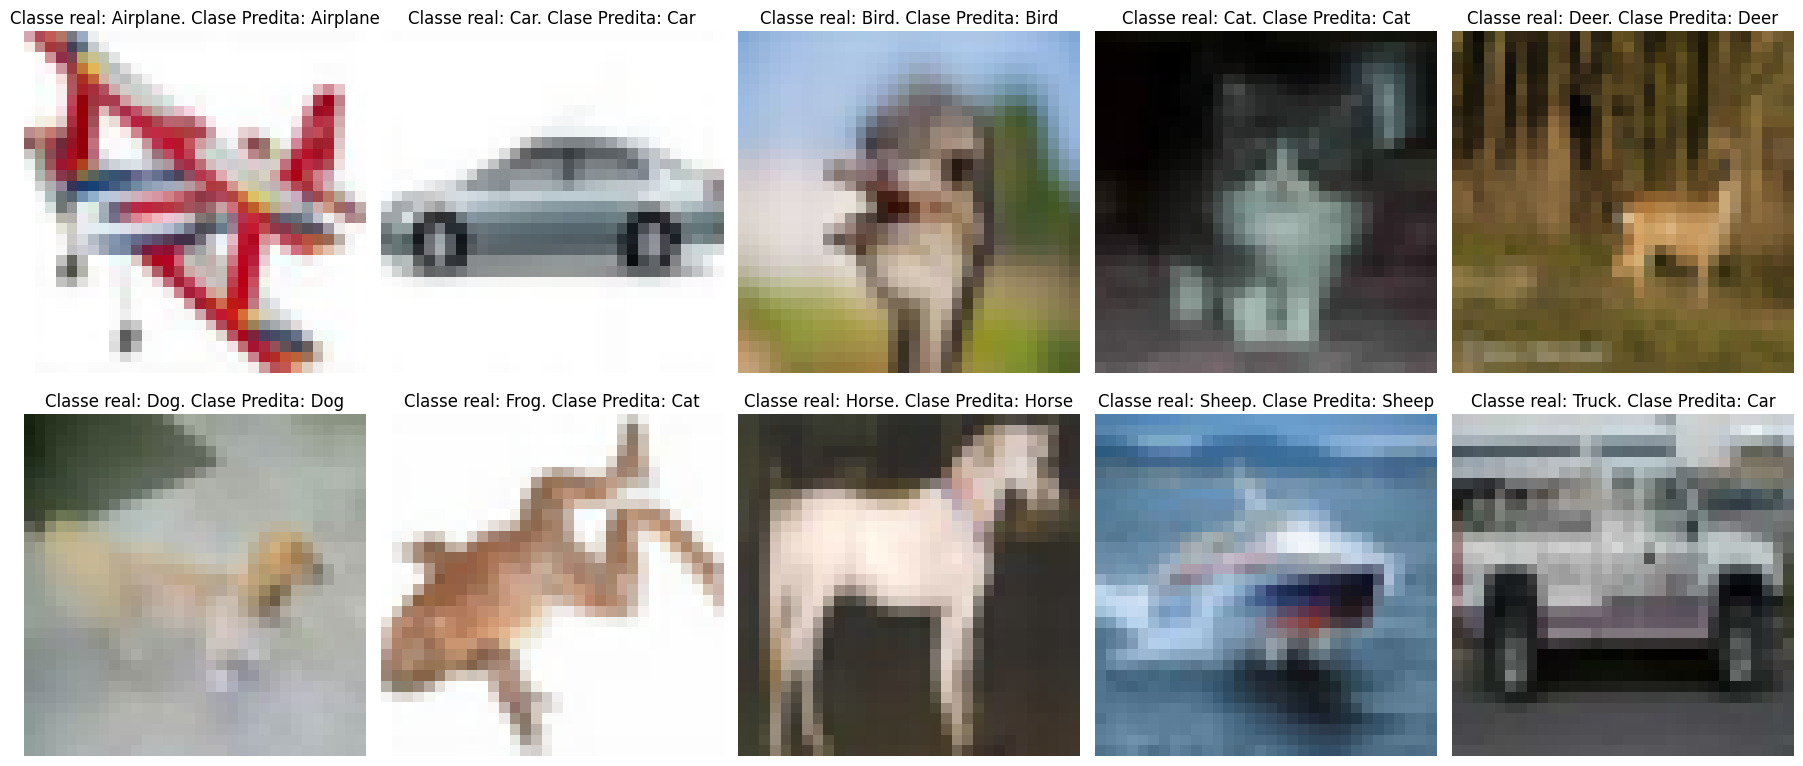

In [ ]:
# best model test
accuracy = trained_cnn3.evaluate(X_test, y_test, batch_size= 456)[1]
probas = trained_cnn3.predict(X_test, batch_size=456, verbose=False)
predictions = np.argmax(probas, axis=1)
conf_matrix = confusion_matrix(y_test, predictions)

print(f"Acurácia do modelo {"New CNN 3"}: {accuracy}")

print(f"Matriz de Confusão do Modelo: ")
print(conf_matrix)
cifar_cnn.test_prediction(trained_cnn3)